## LAION-fMRI practice: single-trial betas on a cortical flatmap

1. Download stimuli
2. Find the labels for each fMRI session
3. Plot a single trial on a flatmap (FreeSurfer patches + matplotlib, no pycortex database needed)

In [1]:
import io
import inspect
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
from nibabel.freesurfer.io import read_geometry
from PIL import Image
from scipy.spatial import cKDTree

import cortex
import cortex.freesurfer as fs
from laion_fmri import load_subject

### Configuration

In [2]:
BASE = Path("/mnt/c/Users/rendo/Documents/BA/laion_fmri_data")
STIMULI_DIR = BASE / "stimuli"
SURF_DIR = BASE / "derivatives" / "freesurfer" / "sub-01" / "surf"

SUBJECT = "sub-01"
SESSION = "ses-01"
ROIS = ["V1v", "V1d", "V2v", "V2d", "V3v", "V3d"]
TRIAL = 10          # which trial (row of `betas`) to plot
MAX_DIST_MM = 3.0   # a surface vertex only gets a value if a voxel is this close

### Load betas and trial info

In [4]:
sub = load_subject(SUBJECT)
betas = sub.get_betas(session=SESSION, roi=ROIS, streaming=True)   # (n_trials, n_roi_voxels)
trials_df = pd.DataFrame(sub.get_trial_info(session=SESSION))
coords = np.asarray(sub.get_voxel_coordinates(roi=ROIS, mask_source="anatomical"))  # (n_roi_voxels, 3)

print("betas:", betas.shape, type(betas))
print("coords:", coords.shape)
assert betas.shape[1] == coords.shape[0], "betas and voxel coordinates must have the same voxel count"
trials_df.head()

betas: (1044, 3621) <class 'numpy.ndarray'>
coords: (3621, 3)


,session,run,beta_index,label
0,ses-01,1,0,unique_LAION_new_cluster_475_i49_p01.jpg
1,ses-01,1,1,unique_LAION_initial_cluster_5192_i30_p01.jpg
2,ses-01,1,2,shared_12rep_LAION_cluster_2677_i5.jpg
3,ses-01,1,3,unique_LAION_initial_cluster_4651_i2_p01.jpg
4,ses-01,1,4,unique_LAION_initial_cluster_3457_i4_p01.jpg


### Stimuli

22187


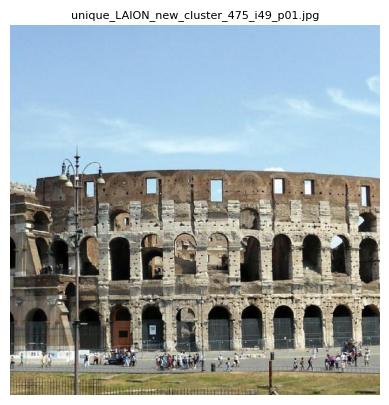

['session', 'run', 'beta_index', 'label']


In [5]:
stim_meta = pd.read_csv(STIMULI_DIR / "task-images_metadata.csv")
h5_path = STIMULI_DIR / "task-images_stimuli.h5"

def show_stimulus(idx):
    with h5py.File(h5_path, "r") as f:
        data = f["images"][idx]
    plt.imshow(Image.open(io.BytesIO(data.tobytes())))
    plt.axis("off")
    plt.title(stim_meta.loc[idx, "image_name"], fontsize=8)
    plt.show()

# look a stimulus up by name, then display it
name = "unique_LAION_new_cluster_475_i49_p01.jpg"
idx = stim_meta.index[stim_meta["image_name"] == name][0]
print(idx)
show_stimulus(idx)

# stimulus shown on the plotted trial (only if the trial table carries image names)
print(trials_df.columns.tolist())
if "image_name" in trials_df.columns:
    t_idx = stim_meta.index[stim_meta["image_name"] == trials_df.loc[TRIAL, "image_name"]][0]
    show_stimulus(t_idx)

### Load FreeSurfer surfaces and check the coordinate spaces match

In [6]:
print(sub.get_freesurfer_dir())

lh_vertices, lh_faces = read_geometry(SURF_DIR / "lh.fiducial")
rh_vertices, rh_faces = read_geometry(SURF_DIR / "rh.fiducial")
print("LH vertices/faces:", lh_vertices.shape, lh_faces.shape)
print("RH vertices/faces:", rh_vertices.shape, rh_faces.shape)

lh_voxels = coords[:, 0] < 0
rh_voxels = coords[:, 0] > 0
print("voxels X<0:", lh_voxels.sum(), " X>0:", rh_voxels.sum(), " X==0:", (coords[:, 0] == 0).sum())

for label, arr in [("voxels", coords), ("LH fiducial", lh_vertices), ("RH fiducial", rh_vertices)]:
    print(f"{label:12s} min {arr.min(axis=0).round(1)}  max {arr.max(axis=0).round(1)}")

/mnt/c/Users/rendo/Documents/BA/laion_fmri_data/derivatives/freesurfer/sub-01
LH vertices/faces: (148371, 3) (296738, 3)
RH vertices/faces: (146299, 3) (292594, 3)
voxels X<0: 1396  X>0: 2225  X==0: 0
voxels       min [-23.5 -85.5 -26.4]  max [ 33.4 -41.1  21.6]
LH fiducial  min [-61.3 -86.6 -31.7]  max [ 7.3 82.9 78. ]
RH fiducial  min [ -3.7 -83.  -29.9]  max [62.9 84.6 79.1]


### Load flat patches

FreeSurfer patch files store *border* vertices with a **negative** index, so the vertex id is `abs(vert) - 1`
(the earlier `vert - 1` gave indices of -148226, which silently wrap around in numpy).

In [7]:
print("pycortex version:", cortex.__version__)

lh_patch = fs.parse_patch(str(SURF_DIR / "lh.cortex.patch.flat"))
rh_patch = fs.parse_patch(str(SURF_DIR / "rh.cortex.patch.flat"))
print(lh_patch.dtype.names, lh_patch.shape, rh_patch.shape)

lh_patch_idx = np.abs(lh_patch["vert"]).astype(np.int64) - 1
rh_patch_idx = np.abs(rh_patch["vert"]).astype(np.int64) - 1
assert lh_patch_idx.max() < len(lh_vertices) and rh_patch_idx.max() < len(rh_vertices)

pycortex version: 1.3.2
('vert', 'x', 'y', 'z') (137276,) (136171,)


### Helper functions

Voxels are mapped to the surface from the **vertex side**: each vertex takes the value of its nearest voxel,
if that voxel is within `MAX_DIST_MM`. (Going voxel -> nearest vertex, as before, only filled about half of the
vertices, which leaves holes in the flatmap.)

### Plot

vertices with values  LH: 1324 / 148371  RH: 1841 / 146299
flat x/y range LH: [-338.  -161.3] [  0.  161.3]  RH: [   5.  -158.6] [351.5 158.6]


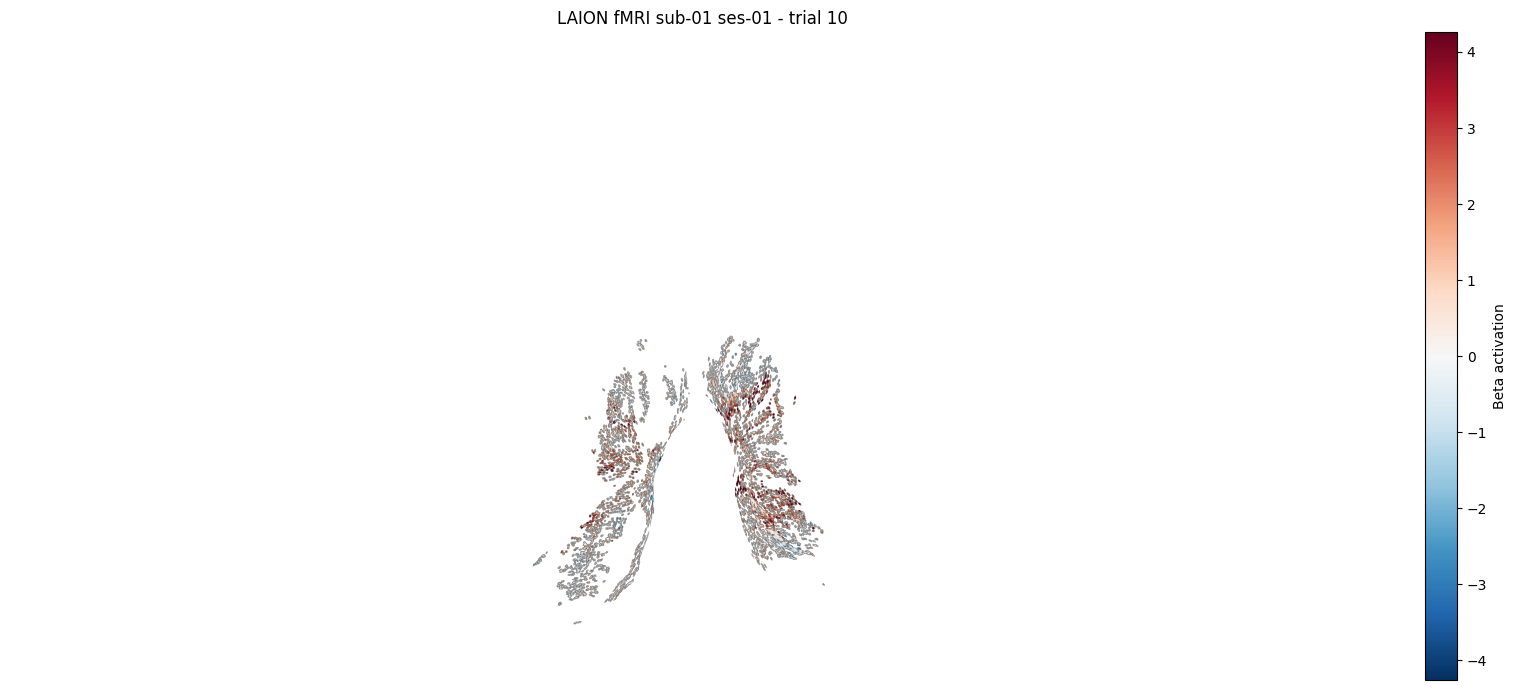

In [11]:
plot_flatmap(TRIAL)